In [1]:
import sys
sys.path.insert(0, '../')
from plotting import *
setup_plotting()

# 3.2 The Newton Direction

Given a current best estimate $x_n$, we can approximate $f$ with a quadratic polynomial. For some small $p$,

$$
f(x_n + p)
\approx
f(x_n) + p^\prime f^\prime(x_n) + \frac{1}{2}p^\prime f^{\prime\prime}(x_n)p.
$$

If we minimize the right hand side with respect to $p$, we obtain
$$
p_n = f^{\prime\prime}(x_n)^{-1}[-f^\prime(x_n)]
$$
which we can think of as the steepest descent direction “twisted” by the inverse of the Hessian matrix $f^{\prime\prime}(x_n)^{-1}$. Newton’s method has a “natural” step length of $1$, so that the updating procedure is

$$
x_{n+1} = x_n - f^{\prime\prime}(x_n)^{-1}f^\prime(x_n).
$$

Newton’s method makes a quadratic approximation to the target function $f$ at each step of the algorithm. This follows the “optimization transfer” principle mentioned earlier, whereby we take a complex function $f$, replace it with a simpler function $g$ that is easier to optimize, and then optimize the simpler function repeatedly until convergence to the solution.

We can visualize how Newton’s method makes its quadratic approximation to the target function easily in one dimension.


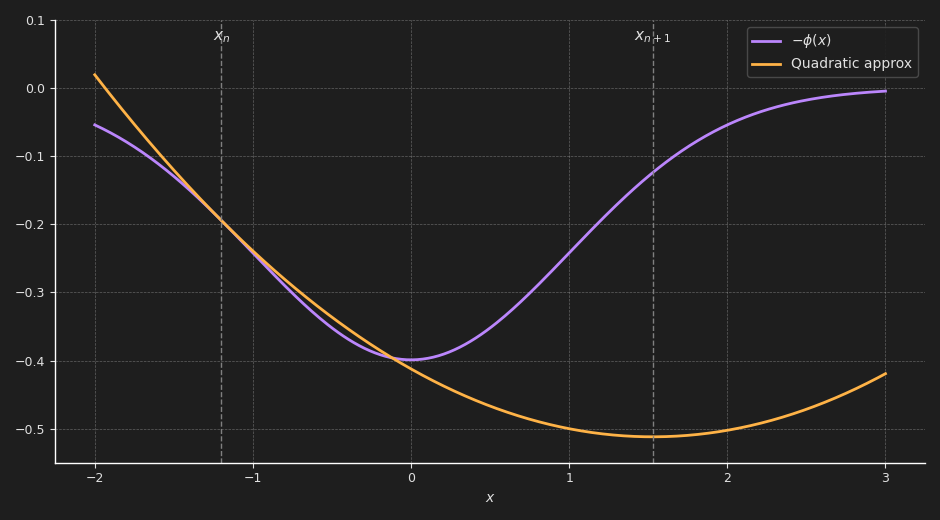

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import optimize, stats

x_grid = np.linspace(-2, 3, 300)

xn = -1.2
g = lambda x: (-stats.norm.pdf(xn) + (x-xn) * xn * stats.norm.pdf(xn)
               - 0.5 * (x-xn)**2 * (stats.norm.pdf(xn) - xn * (xn * stats.norm.pdf(xn))))

op = optimize.minimize_scalar(g, bounds=(0, 3), method='bounded')

fig, ax = plt.subplots()
ax.plot(x_grid, -stats.norm.pdf(x_grid), lw=2, label='$-\\phi(x)$')
ax.plot(x_grid, [g(xi) for xi in x_grid], color=C['orange'], label='Quadratic approx')
ax.axvline(xn, linestyle='--', color='gray', lw=1)
ax.axvline(op.x, linestyle='--', color='gray', lw=1)
ax.set_ylim(-0.55, 0.1)
ax.text(xn, 0.07, '$x_n$', ha='center', fontsize=11)
ax.text(op.x, 0.07, '$x_{n+1}$', ha='center', fontsize=11)
ax.legend(fontsize=10)
ax.set_xlabel('$x$')
plt.tight_layout()


In the above figure, the next iterate, $x_{n+1}$ is actually further away from the minimum than our previous iterate $x_n$. The quadratic approximation that Newton’s method makes to $f$ is not guaranteed to be good at every point of the function.

This shows an important “feature” of Newton’s method, which is that it is not *monotone*. The successive iterations that Newton’s method produces are not guaranteed to be improvements in the sense that each iterate is closer to the truth. The tradeoff here is that while Newton’s method is very fast (quadratic convergence), it can be unstable at times. Monotone algorithms (like the EM algorithm that we discuss later) that always produce improvements, are more stable, but generally converge at slower rates.

In the next figure, however, we can see that the solution provided by the next approximation, $x_{n+2}$, is indeed quite close to the true minimum.


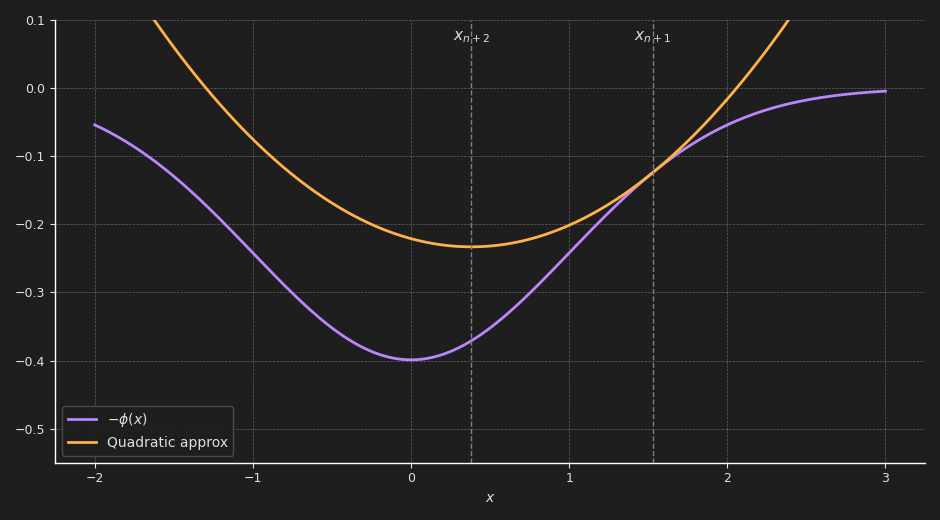

In [3]:
x_grid = np.linspace(-2, 3, 300)

# Compute x_{n+1} from xn = -1.2
xn_0 = -1.2
g_0 = lambda x: (-stats.norm.pdf(xn_0) + (x-xn_0) * xn_0 * stats.norm.pdf(xn_0)
                  - 0.5 * (x-xn_0)**2 * (stats.norm.pdf(xn_0) - xn_0 * (xn_0 * stats.norm.pdf(xn_0))))
op1 = optimize.minimize_scalar(g_0, bounds=(0, 3), method='bounded')

xn = op1.x  # x_{n+1}
g = lambda x: (-stats.norm.pdf(xn) + (x-xn) * xn * stats.norm.pdf(xn)
               - 0.5 * (x-xn)**2 * (stats.norm.pdf(xn) - xn * (xn * stats.norm.pdf(xn))))
op2 = optimize.minimize_scalar(g, bounds=(0, 3), method='bounded')

fig, ax = plt.subplots()
ax.plot(x_grid, -stats.norm.pdf(x_grid), lw=2, label='$-\\phi(x)$')
ax.plot(x_grid, [g(xi) for xi in x_grid], color=C['orange'], label='Quadratic approx')
ax.axvline(xn, linestyle='--', color='gray', lw=1)
ax.axvline(op2.x, linestyle='--', color='gray', lw=1)
ax.set_ylim(-0.55, 0.1)
ax.text(xn, 0.07, '$x_{n+1}$', ha='center', fontsize=11)
ax.text(op2.x, 0.07, '$x_{n+2}$', ha='center', fontsize=11)
ax.legend(fontsize=10)
ax.set_xlabel('$x$')
plt.tight_layout()


It is worth noting that in the rare event that $f$ is in fact a quadratic polynomial, Newton’s method will converge in a single step because the quadratic approximation that it makes to $f$ will be exact.

### Generalized Linear Models

The generalized linear model is an extension of the standard linear model to allow for non-Normal response distributions. The distributions used typically come from an exponential family whose density functions share some common characteristics. With a GLM, we typical present it as $y_i\sim p(y_i\mid\mu_i)$, where $p$ is an exponential family distribution, $\mathbb{E}[y_i]=\mu_i$,

$$
g(\mu_i) = x_i^\prime\beta,

$$

where $g$ is a nonlinear link function, and $\text{Var}(y_i) = V(\mu)$ where $V$ is a known variance function.

Unlike the standard linear model, the maximum likelihood estimate of the parameter vector $\beta$ cannot be obtained in closed form, so an iterative algorithm must be used to obtain the estimate. The traditional algorithm used is the Fisher scoring algorithm. This algorithm uses a linear approximation to the nonlinear link function $g$, which can be written as

$$
g(y_i)\approx g(\mu_i) + (y_i-\mu_i)g^\prime(\mu_i).

$$

The typical notation of GLMs refers to $z_i=g(\mu_i) + (y_i-\mu_i)g^\prime(\mu_i)$ as the *working response*. The Fisher scoring algorithm then works as follows.

1. Start with $\hat{\mu}_i$, some initial value.
2. Compute $z_i = g(\hat{\mu}_i) + (y_i-\hat{\mu}_i)g^\prime(\hat{\mu}_i)$.
3. Given the $n\times 1$ vector of working responses $z$ and the $n\times p$ predictor matrix $X$ we compute a weighted regression of $z$ on $X$ to get

$$
\beta_n = (X^\prime WX)^{-1}X^\prime Wz

$$

where $W$ is a diagonal matrix with diagonal elements

$$
w_{ii} = \left[g^\prime(\mu_i)^2V(\mu_i)\right]^{-1}.

$$
4. Given $\beta_n$, we can recompute $\hat{\mu}_i=g^{-1}(x_i^\prime\beta_n)$ and go to 2.

Note that in Step 3 above, the weights are simply the inverses of the variance of $z_i$, i.e. 

$$
\begin{eqnarray*}
\text{Var}(z_i)
& = &
\text{Var}(g(\mu_i) + (y_i-\mu_i)g^\prime(\mu_i))\\
& = &
\text{Var}((y_i-\mu_i)g^\prime(\mu_i))\\
& = & V(\mu_i)g^\prime(\mu_i)^2
\end{eqnarray*}

$$

Naturally, when doing a weighted regression, we would weight by the inverse of the variances.

#### Example: Poisson Regression

For a Poisson regression, we have $y_i\sim\text{Poisson}(\mu_i)$ where $g(\mu) = \log\mu_i = x_i^\prime\beta$ because the log is the canonical link function for the Poisson distribution. We also have $g^\prime(\mu_i) = \frac{1}{\mu_i}$ and $V(\mu_i) = \mu_i$. Therefore, the Fisher scoring algorithm is

1. Initialize $\hat{\mu}_i$, perhaps using $y_i + 1$ (to avoid zeros).
2. Let 

$$
z_i = \log\hat{\mu}_i + (y_i-\hat{\mu}_i)\frac{1}{\hat{\mu}_i}
$$


3. Regression $z$ on $X$ using the weights

$$
w_{ii} = \left[\frac{1}{\hat{\mu}_i^2}\hat{\mu}_i\right]^{-1} = \hat{\mu}_i.

$$

Using the Poisson regression example, we can draw a connection between the usual Fisher scoring algorithm for fitting GLMs and Newton’s method. Recall that if $\ell(\beta)$ is the log-likelihood as a function of the regression paramters $\beta$, then the Newton updating scheme is

$$
\beta_{n+1} = \beta_n + \ell^{\prime\prime}(\beta_n)^{-1}[-\ell^\prime(\beta_n)].

$$

The log-likelihoood for a Poisson regression model can be written in vector/matrix form as

$$
\ell(\beta) = y^\prime X\beta - \exp(X\beta)^\prime\mathbf{1}

$$

where the exponential is taken component-wise on the vector $X\beta$. The gradient function is

$$
\ell^\prime(\beta) = X^\prime y - X^\prime \exp(X\beta)
=
X^\prime(y-\mu)

$$

and the Hessian is

$$
\ell^{\prime\prime}(\beta) = -X^\prime W X

$$

where $W$ is a diagonal matrix with the values $w_{ii} = \exp(x_i^\prime\beta)$ on the diagonal. The Newton iteration is then

$$
\begin{eqnarray*}
\beta_{n+1}
& = &
\beta_n + (-X^\prime WX)^{-1}(-X^\prime(y-\mu))\\
& = &
\beta_n + (X^\prime WX)^{-1}XW(z - X\beta_n)\\
& = &
(X^\prime WX)^{-1}X^\prime Wz + \beta_n - (X^\prime WX)^{-1}X^\prime WX\beta_n\\
& = &
(X^\prime WX)^{-1}X^\prime Wz
\end{eqnarray*}

$$

Therefore the iteration is exactly the same as the Fisher scoring algorithm in this case. In general, Newton’s method and Fisher scoring will coincide with any generalized linear model using an exponential family with a canonical link function.

### Newton's Method in Python

`scipy.optimize.minimize` implements a variety of optimization methods for minimizing a function. As an example, we use its BFGS method — a quasi-Newton method — to fit a simple logistic regression model for binary data. This model specifies that $y_i\sim\text{Bernoulli}(p_i)$ where

$$
\log\frac{p_i}{1-p_i} = \beta_0 + x_i \beta_1
$$

and the goal is to estimate $\beta$ via maximum likelihood. The negative log-likelihood is

$$
\text{NLL}(\beta) = -\sum_{i=1}^n \left[ y_i(\beta_0 + x_i\beta_1) - \log\left(1+e^{\beta_0 + x_i\beta_1}\right) \right].
$$

#### Example: Challenger O-ring Failures

We model the probability of O-ring damage on NASA Space Shuttle flights as a function of launch temperature. The data include 23 launches prior to the 1986 Challenger disaster.

In [4]:
challenger = pd.read_csv('../data/challenger_data.csv')
challenger = challenger[pd.to_numeric(challenger['Damage Incident'], errors='coerce').notna()].copy()
x = challenger['Temperature'].values.astype(float)
y = challenger['Damage Incident'].values.astype(float)
print(f"n = {len(x)}, events = {int(y.sum())}")

def nll_logistic(beta, x, y):
    """Negative log-likelihood for logistic regression."""
    eta = beta[0] + beta[1] * x
    return -np.sum(y * eta - np.logaddexp(0.0, eta))

res = optimize.minimize(
    nll_logistic, x0=[0.0, 0.0], args=(x, y),
    method='BFGS',
    options={'disp': False}
)
b0, b1 = res.x
print(f"beta_0 = {b0:.4f}, beta_1 = {b1:.4f}")
print(f"Convergence: {res.message}")

n = 23, events = 7
beta_0 = 15.0430, beta_1 = -0.2322
Convergence: Optimization terminated successfully.


The negative coefficient on temperature indicates that lower temperatures are associated with higher O-ring failure probability. We can visualize the fitted curve.

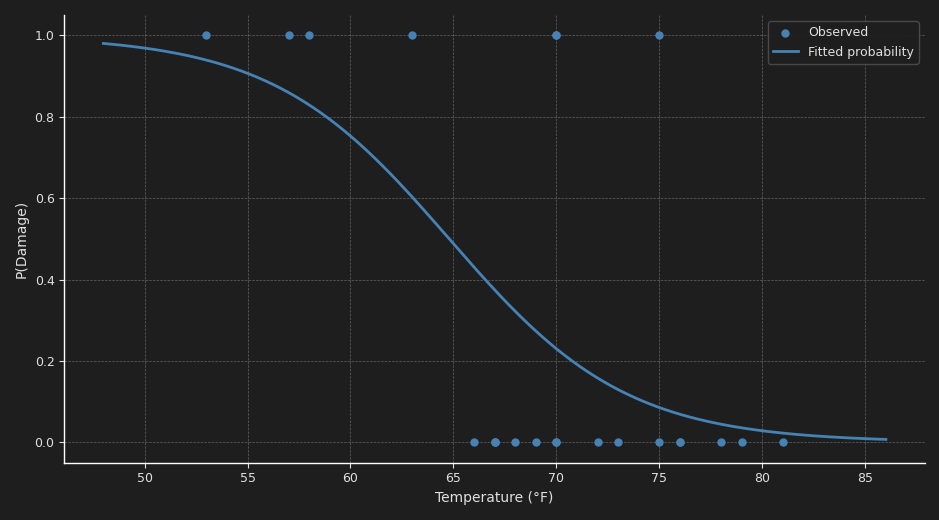

In [5]:
temp_grid = np.linspace(x.min() - 5, x.max() + 5, 200)
prob_fit = 1 / (1 + np.exp(-(b0 + b1 * temp_grid)))

fig, ax = plt.subplots()
ax.scatter(x, y, color='steelblue', zorder=3, label='Observed')
ax.plot(temp_grid, prob_fit, color='steelblue', label='Fitted probability')
ax.set_xlabel('Temperature (°F)')
ax.set_ylabel('P(Damage)')
ax.legend()
plt.tight_layout()